In [325]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [327]:
df = pd.read_csv("/Users/tobiasshin/Downloads/Data Exercise Fall 2025.csv")

In [31]:
df

,Date,TimeOfDay,Spot,BuyTrader,SellTrader
0,1/3/2022,9:32:05,99.96,3,0
1,1/3/2022,9:34:11,99.98,4,5
2,1/3/2022,9:34:29,99.97,4,5
3,1/3/2022,9:34:44,99.96,4,0
4,1/3/2022,9:39:02,99.88,3,1
...,...,...,...,...,...
120243,12/30/2022,15:50:09,115.70,2,0
120244,12/30/2022,15:50:39,115.73,3,0
120245,12/30/2022,15:51:31,115.74,2,4
120246,12/30/2022,15:56:58,115.86,2,0


In [33]:
df.isna().sum()

Date          0
TimeOfDay     0
Spot          0
BuyTrader     0
SellTrader    0
dtype: int64

In [35]:
df.info

<bound method DataFrame.info of               Date TimeOfDay    Spot  BuyTrader  SellTrader
0         1/3/2022   9:32:05   99.96          3           0
1         1/3/2022   9:34:11   99.98          4           5
2         1/3/2022   9:34:29   99.97          4           5
3         1/3/2022   9:34:44   99.96          4           0
4         1/3/2022   9:39:02   99.88          3           1
...            ...       ...     ...        ...         ...
120243  12/30/2022  15:50:09  115.70          2           0
120244  12/30/2022  15:50:39  115.73          3           0
120245  12/30/2022  15:51:31  115.74          2           4
120246  12/30/2022  15:56:58  115.86          2           0
120247  12/30/2022  15:57:26  115.84          5           0

[120248 rows x 5 columns]>

In [37]:
df.columns

Index(['Date', 'TimeOfDay', 'Spot', 'BuyTrader', 'SellTrader'], dtype='object')

In [39]:
df.groupby('Date').count()

,TimeOfDay,Spot,BuyTrader,SellTrader
Date,,,,
1/10/2022,492,492,492,492
1/11/2022,470,470,470,470
1/12/2022,442,442,442,442
1/13/2022,481,481,481,481
1/14/2022,524,524,524,524
...,...,...,...,...
9/30/2022,460,460,460,460
9/6/2022,477,477,477,477
9/7/2022,479,479,479,479


In [41]:
print(df['Spot'].mean())
print(df['Spot'].median())
print(df['Spot'].mode())

102.77673865677599
101.8
0    94.42
Name: Spot, dtype: float64


In [43]:
df['Spot'].value_counts()

Spot
94.42     146
94.44     141
94.43     136
107.35    135
94.13     132
         ... 
119.88      1
88.59       1
89.24       1
89.26       1
115.40      1
Name: count, Length: 3111, dtype: int64

In [45]:
df['BuyTrader'].value_counts()

BuyTrader
0    46188
4    21113
2    17878
5    16906
3    10570
1     7018
6      575
Name: count, dtype: int64

In [47]:
df['SellTrader'].value_counts()

SellTrader
0    56763
4    21113
2    17878
5    16906
1     7018
6      570
Name: count, dtype: int64

In [49]:
"""
7x7 matrix where (i,j) denotes how often trader i is Buying from Seller trader j
eg, trader 0 buys from trader 4 most often over the entire data set
moreover, we see trader 3 never sells

Matrix shows that everyone buys from trader 0 the most often, then from trader 4 the most often
Traders 4, 2, 5, 1 buy/sell the same amount of total inventory resp.  Same with trader 6 except for 5 sell trades
Trader 3 never sells ever
"""

counts = (
    df.groupby(["BuyTrader", "SellTrader"])
      .size()
      .unstack(fill_value=0)   # columns = SellTrader, rows = BuyTrader
      .reindex(index=range(7), columns=range(7), fill_value=0)
)

counts

SellTrader,0,1,2,3,4,5,6
BuyTrader,,,,,,,
0,0,4975,12984,0,15800,12217,212
1,5189,0,610,0,627,545,47
2,14005,537,0,0,1828,1439,69
3,7434,314,913,0,1034,820,55
4,16743,645,1831,0,0,1806,88
5,13126,511,1472,0,1698,0,99
6,266,36,68,0,126,79,0


In [300]:
df['Datetime'] = pd.to_datetime(df['Date'].astype(str) + " " + df['TimeOfDay'].astype(str))

In [329]:
"""
Want to analyze trader behavior every ten min, since time is from 9:30--16:00 that's 39 bins
"""
bin_df = df.copy()
bin_df["Datetime"] = pd.to_datetime(bin_df["Date"].astype(str) + " " + bin_df["TimeOfDay"].astype(str))


#minutes since open (09:30)
open_dt = pd.to_datetime(bin_df["Date"].astype(str) + " 09:30:00")
bin_df["minutes_since_open"] = (bin_df["Datetime"] - open_dt).dt.total_seconds() / 60
bin_df["session_10min"] = (bin_df["minutes_since_open"] // 10).astype(int)

#keep only regular session
bin_df = bin_df[(bin_df["session_10min"] >= 0) & (bin_df["session_10min"] <= 38)]


In [150]:
print("Monotonic:", bin_df['Datetime'].is_monotonic_increasing)
print("Strictly increasing:", (bin_df['Datetime'].diff().iloc[1:] > pd.Timedelta(0)).all())
print("Duplicates:", bin_df['Datetime'].duplicated().sum())

Monotonic: True
Strictly increasing: True
Duplicates: 0


In [170]:
def plot_trader_activity_10min(df, trader_id):
    buy_counts = df.loc[df["BuyTrader"] == trader_id, "session_10min"].value_counts().sort_index()
    sell_counts = df.loc[df["SellTrader"] == trader_id, "session_10min"].value_counts().sort_index()

    bins = pd.Index(range(39), name="session_10min")
    buy_counts = buy_counts.reindex(bins, fill_value=0)
    sell_counts = sell_counts.reindex(bins, fill_value=0)

    #total = buy_counts + sell_counts

    labels = []
    for i in range(39):
        start = pd.Timestamp("09:30") + pd.Timedelta(minutes=10*i)
        end = start + pd.Timedelta(minutes=10)
        labels.append(f"{start.strftime('%H:%M')}")

    x = np.arange(len(bins))
    width = 0.4

    plt.figure(figsize=(14, 4))

    #originally plotted full volumes of buy/sell counts
    #but to analyze behavior, better to look at average 
    plt.bar(x-width/2, buy_counts.values/buy_counts.values.sum(), width=width, label="Buy trades")
    plt.bar(x+width/2, sell_counts.values/sell_counts.values.sum(), width=width, label="Sell trades")

    plt.xticks(x[::3], labels[::3], rotation=45)  # show every 3rd label for readability
    plt.ylabel("Number of trades")
    plt.title(f"Trader {trader_id} activity by 10-minute interval")
    plt.legend()
    plt.tight_layout()
    plt.show()

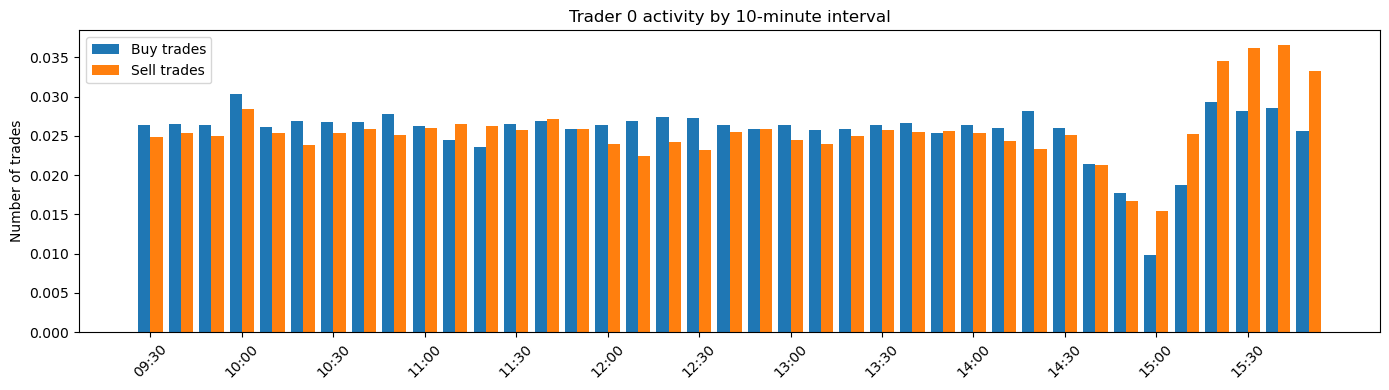

In [172]:
plot_trader_activity_10min(bin_df, trader_id=0)

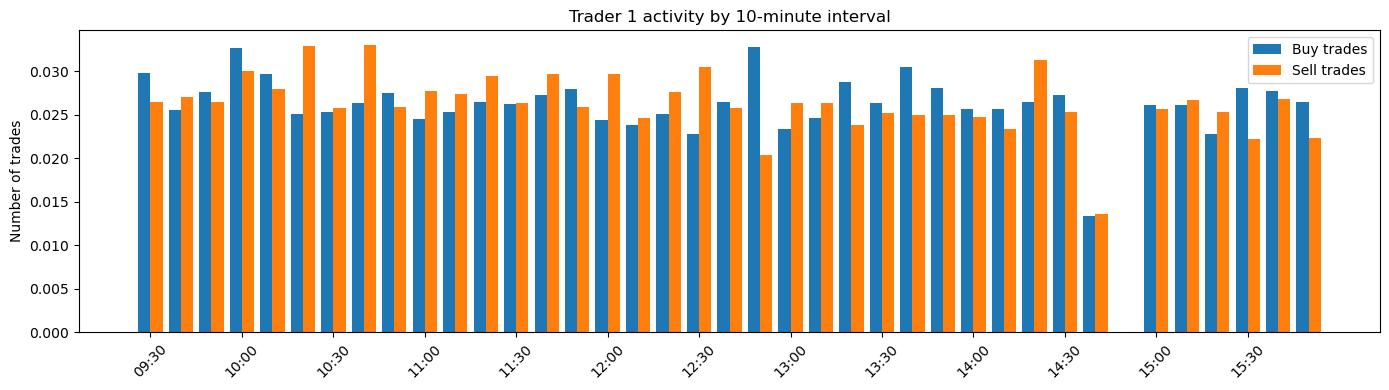

In [174]:
plot_trader_activity_10min(bin_df, trader_id=1)

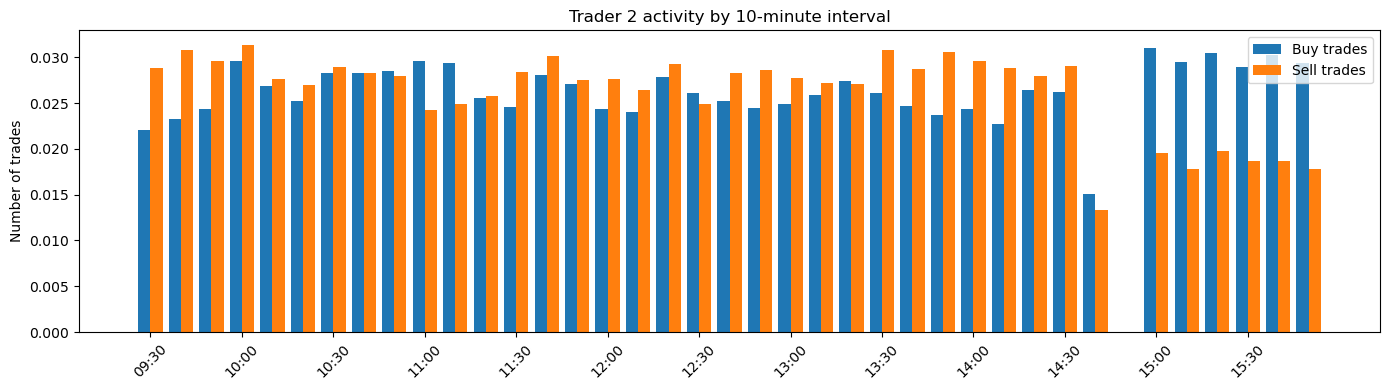

In [176]:
plot_trader_activity_10min(bin_df, trader_id=2)

/var/folders/6y/j4l74v9d1c58317bz7b96ztr0000gn/T/ipykernel_83354/2242455122.py:22: RuntimeWarning: invalid value encountered in divide
  plt.bar(x+width/2, sell_counts.values/sell_counts.values.sum(), width=width, label="Sell trades")


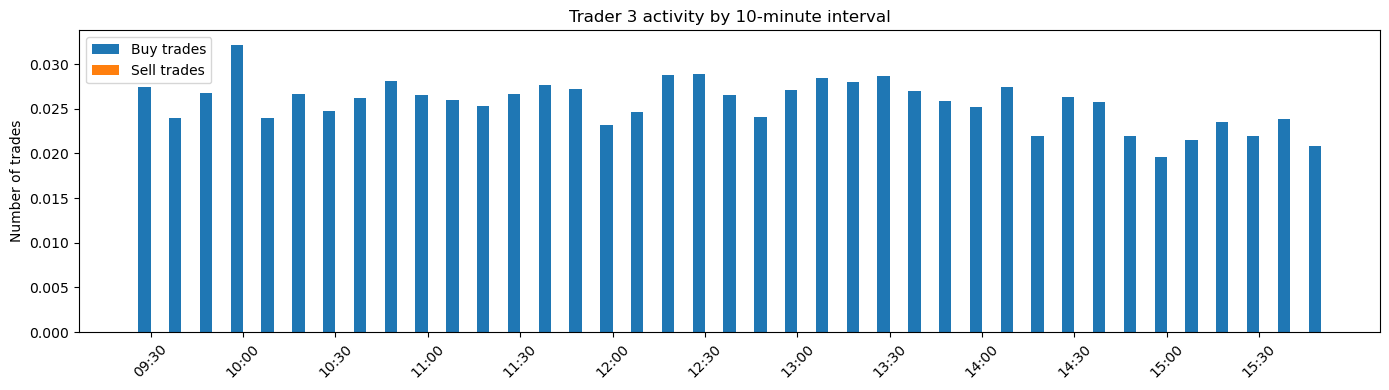

In [178]:
plot_trader_activity_10min(bin_df, trader_id=3)

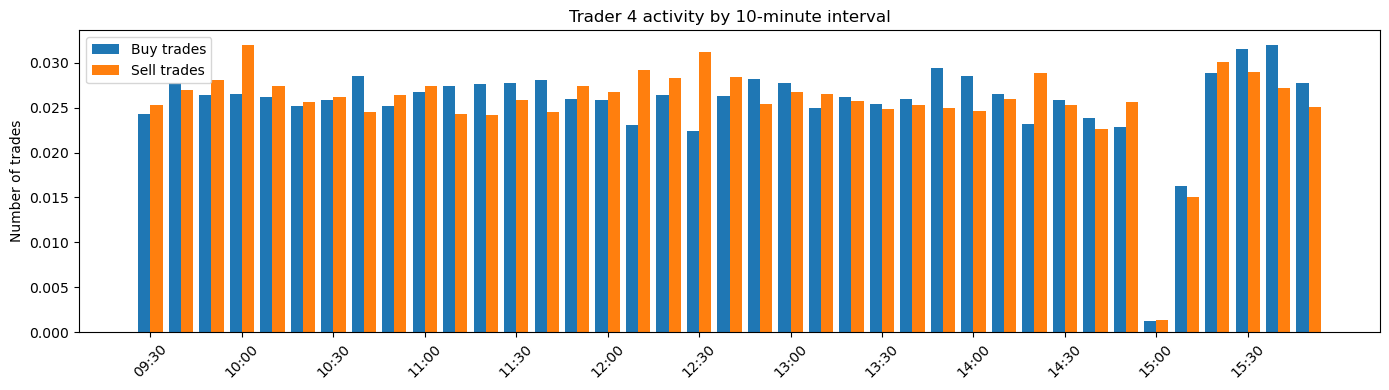

In [180]:
plot_trader_activity_10min(bin_df, trader_id=4)

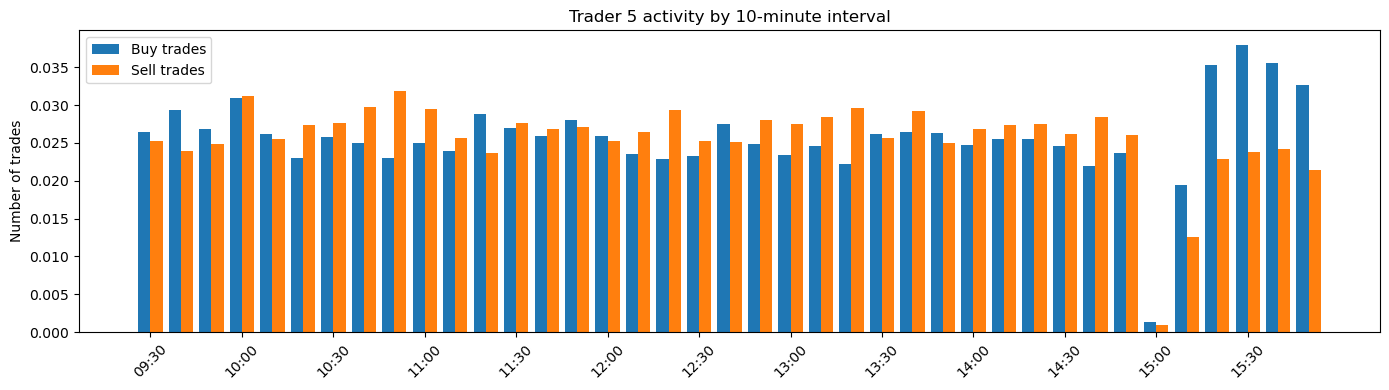

In [182]:
plot_trader_activity_10min(bin_df, trader_id=5)

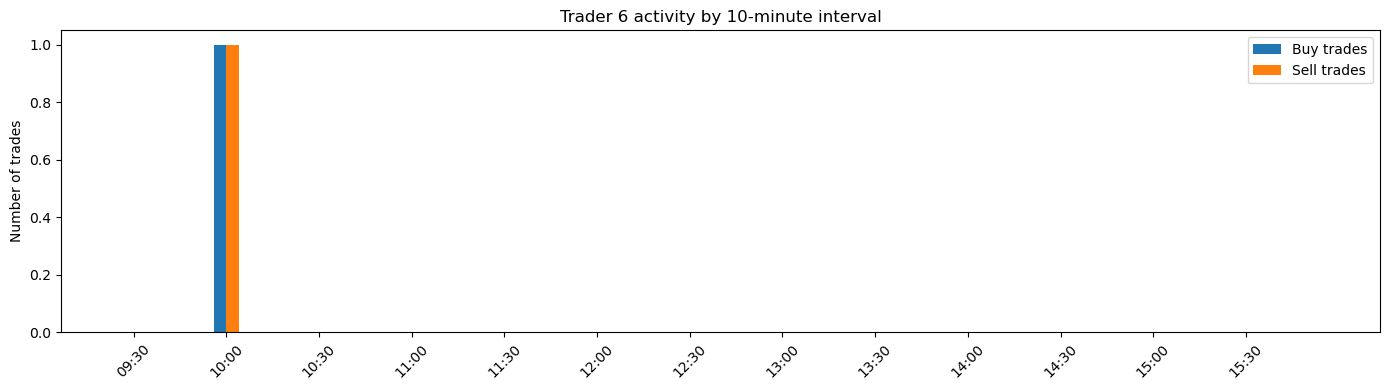

In [184]:
plot_trader_activity_10min(bin_df, trader_id=6)

In [168]:
sixtrade = bin_df[(bin_df["BuyTrader"] == 6) | (bin_df["SellTrader"] == 6)]


print((sixtrade["Datetime"].dt.time > pd.to_datetime("10:10:00").time()).value_counts())
print((sixtrade["Datetime"].dt.time < pd.to_datetime("10:00:00").time()).value_counts())

"""
Trader 6 only trades from 10--10:10
"""

Datetime
False    1145
Name: count, dtype: int64
Datetime
False    1145
Name: count, dtype: int64


'\nTrader 6 only trades from 10--10:10\n'

In [21]:
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['TimeOfDay'])
df.drop(columns=['Date','TimeOfDay'])
df = df[['Datetime', 'Spot', 'BuyTrader', 'SellTrader']]

In [ ]:
"""
Trader 0 buys and sells throughout the day, usually buying more and then massive sell-off at end-of-day
Trader 1, 2, 4, 5 have somewhat similar trading behaviors
    1 and 2 stop trading at around 14:50
    4 and 5 have minimal trades around 15:00
however 2 and 5 buy a lot towards end-of-day

Trader 3 never sells, only buys
Trader 6 only trades in a 10 min window, from 10--10:10 

Now we should analyze if these trading behaviors are informed (or misinformed);
    first we assume the stock price follows some kind of Brownian motion or martingale (past price does not predict future prices)
    this also helps our model as then non-overlapping x-minute forward returns  R(t) = [P(t+x) - P(t) / P(t)] are independent
    This is not literally true, as we have a lot of overlapping forward returns. But as a rough baseline let's take x to be small (5 min)
        and assume independent returns

Then we do hypothesis testing:
H0: E(x-min return | trader i buys/sells) = 0
If a given trader in a certain side (say in a given hour) is truly uninformed and trades arbitrarily, the average return should be 0
    (per the Brownian motion / martingale model)
Since we don't know the variance, we have to use t-score , which for iid samples is given by (sample mean) / sqrt((sample variance)/# of samples))

Depending on the side, it's a 1-sided t-test
If trader buys, and t >> 2, then this implies trader is buying before price increases (average return is positive). So trader is informed
Likewise, if trader sells, and t << -2, then this implies trader is selling before price decreases (average return negative). So trader is informed
So we want to AVOID trading with informed traders

Conversely,
if trader buys and t << -2, they are buying before price decreases. So they are actively uninformed (ill-informed?)
and if trader sells and t >> 2, they are selling before price increases. So again actively uninformed
We want to trade with these traders as much as possible to maximize profit
Since we need to end the day with no position, we want to maximize day-to-day expected profit

So we'll compute the t-scores for the different traders for each side, for each hour
then find the best times to trade with ill-informed traders and stop trading immediately if we trade with a well-informed trader.

Note on dependence: another model we could use is assume the day-by-day trades are independent, and use the sample means PER DAY as 
    our individual samples (along with computing variance of those sample means). This is another model ; need to compare PnL with first model

Otherwise we could also bite the bullet and use dependent samples; but then our t-scores will be inflated
    They'll be inflated by however much overlapping windows auto-correlate with each other; depending on how bad it is,
    this may not affect qualitative analysis so much
"""

In [331]:
bin_df = bin_df.drop(columns=['Date','TimeOfDay'])

In [333]:
bin_df = bin_df.drop(columns=['minutes_since_open', 'session_10min'])

In [335]:
bin_df.columns

Index(['Spot', 'BuyTrader', 'SellTrader', 'Datetime'], dtype='object')

In [236]:
"""
Compute 10min returns
"""
price_10 = bin_df.set_index("Datetime")["Spot"].resample("10min").last()
ret_10 = price_10.pct_change(fill_method=None).dropna()

print(ret_10.mean())
print(ret_10.std())

1.1116113185559778e-05
0.0013188429598428707


In [238]:
price_20 = bin_df.set_index("Datetime")["Spot"].resample("20min").last()
ret_20 = price_20.pct_change(fill_method=None).dropna()

print(ret_20.mean())
print(ret_20.std())

2.436061445443057e-05
0.0018755443322615662


In [240]:
price_30 = bin_df.set_index("Datetime")["Spot"].resample("30min").last()
ret_30 = price_30.pct_change(fill_method=None).dropna()

print(ret_30.std()/ret_20.std())
print(ret_20.std()/ret_10.std()*np.sqrt(1.5))

1.2152817961655333
1.741726173583693


In [242]:
print(ret_30.std()/ret_10.std())

1.7282686068783228


In [ ]:
"""
Brownian motion has Var(r_∆) proportional to ∆
so quick sanity check on standard deviations scaling with time appropriately
"""

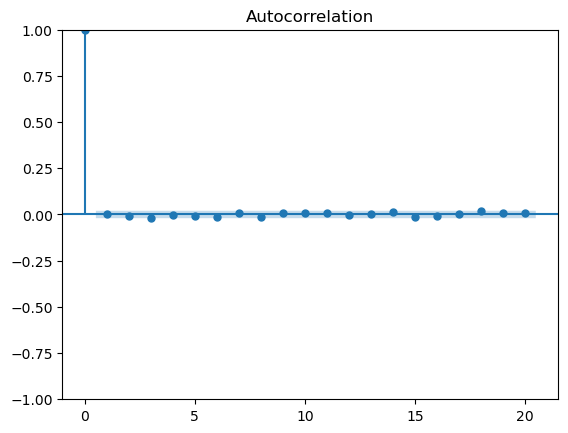

In [248]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(ret_10, lags=20)
plt.show()

In [252]:
"""
Autocorrelation of returns behaves as one would expect under martingale; ie nonoverlapping returns are roughly independent
(autocorrelations close to 0). So supports model of stock price as BM 
Can still have dependence on squared returns (volatility) 
"""

for lag in range(1, 6):
    print(lag, ret_10.autocorr(lag=lag))

1 0.0006326847574682185
2 -0.00676158007516222
3 -0.018178948958849042
4 -0.00046871806921612846
5 -0.010171062461350626


In [337]:
bin_df = bin_df.set_index("Datetime")

In [339]:
"""
Now we compute t-scores for each trader, for each side (buy or sell)
We use 5-min returns

Code below computes bucket returns (we take 5min return of spot price in a given 5 min range window and assign it to all trades in that window)
This slightly inflates t-score since we could be assigning same return multiple times to a trader if they trade frequently
    (creates artificially more samples); the number of independent samples are the # of 5min windows, but there are artifically more samples
        since we record a return for each trade.

T-score gets inflated by roughly sqrt(k) where k = average number of trades per window 
"""

price_5 = bin_df['Spot'].resample('5min').last()
ret_5 = price_5.pct_change(fill_method=None).shift(-1).dropna() #for forward returns


bin_df["5minReturn"] = ret_5.reindex(bin_df.index, method="ffill")

def trader_stats(df, side):
    grouped = df.groupby(side)["5minReturn"]
    
    mean = grouped.mean()
    var = grouped.var()
    count = grouped.count()
    std = grouped.std()
    tscore = mean / (std / np.sqrt(count))

    out = pd.DataFrame({
        "Trader": mean.index,
        "Mean": mean.values,
        "Var": var.values,
        "Count": count.values,
        "Tscore": tscore.values
    })
    return out

sell_side = trader_stats(bin_df, "SellTrader")
buy_side = trader_stats(bin_df, "BuyTrader")

In [341]:
sell_side

,Trader,Mean,Var,Count,Tscore
0,0,0.000065,8.378967e-07,56763,17.015406
1,1,-0.000023,8.789853e-07,7018,-2.020164
2,2,-0.000073,8.392991e-07,17878,-10.693542
3,4,-0.000043,8.687474e-07,21113,-6.736880
4,5,-0.000017,8.629214e-07,16906,-2.366205
5,6,0.000063,7.681789e-07,570,1.720350


In [343]:
buy_side

,Trader,Mean,Var,Count,Tscore
0,0,-0.000055,8.632318e-07,46188,-12.799545
1,1,0.000016,8.489460e-07,7018,1.487865
2,2,0.000096,8.479401e-07,17878,13.932838
3,3,-0.000020,8.412585e-07,10570,-2.244082
4,4,0.000065,8.343052e-07,21113,10.315522
5,5,0.000033,8.297616e-07,16906,4.774723
6,6,0.000144,9.363408e-07,575,3.557584


In [361]:
bin_df["bucket"] = bin_df.index.floor("5min")

In [ ]:
"""
Comment about t-score inflation: suppose we have B buckets (where bucket is a 5min window)
and bucket k has return R_k
and trader makes m_k trades in bucket k
with total # of trades n = sum_k=1^B m_k

the sample mean Rbar of returns (if we sample over all trades) is 1/n * sum_k=1^B m_k*R_k
buckets are independent, and Var(R_k) = sigma^2 = s^2
so Var(Rbar) = 1/n^2 sum m_k^2*Var(R_k) = s^2/n^2 * sum m_k^2 (we're doing t-stat on trades, not buckets)

naive t-stat computes standard error as s/n assuming n independent samples; but now we have samples that arise artifically by being in the same bucket
ie the n trades are not independent because they are assigned the same bucket return
so SE(Rbar) / SE(naive t-stat)  = sqrt( sum m_k^2 ) / sqrt(n)
but n = sum_k m_k so this is the same as sqrt ( sum m_k^2 / sum m_k)
so t-score gets inflated by this amount

although theoretically the returns are independent, by grouping them into 5 min buckets, this introduces dependence on the actual returns we do measure
"""

In [363]:
def inflation_factor(df, trader_id, trader_col):
    m = (df[df[trader_col] == trader_id]
         .groupby("bucket")
         .size()
         .to_numpy())
    if m.size == 0:
        return np.nan
    return np.sqrt((m**2).sum() / m.sum()) #inflation roughly by sqrt( sum m_k^2 / sum m_k) where m = # of trades in bucket k

# example: adjust naive t-scores computed earlier
for i in range(7):
    infl = inflation_factor(bin_df, i, "BuyTrader")
    #print(i, infl)
    t_naive = buy_side['Tscore'].iloc[i]
    print("Trader " + str(i) + ": Buy_side T-score: " + str(t_naive) + " and adjusted:" + str(t_naive / infl)) 

Trader 0: Buy_side T-score: -12.799544943558141 and adjusted:-6.352430804437564
Trader 1: Buy_side T-score: 1.4878650146607018 and adjusted:1.1381203576542112
Trader 2: Buy_side T-score: 13.932837863472141 and adjusted:8.276549412508842
Trader 3: Buy_side T-score: -2.244081925670131 and adjusted:-1.7958976990471993
Trader 4: Buy_side T-score: 10.31552204425966 and adjusted:5.762911027906992
Trader 5: Buy_side T-score: 4.774722691221359 and adjusted:2.850397316095638
Trader 6: Buy_side T-score: 3.557583725959545 and adjusted:1.5106428257495934


In [389]:
for i in range(6):
    infl = inflation_factor(bin_df, i, "SellTrader")
    #print(i, infl)
    if i == 3:
        print("Trader 3 does not sell")
        continue
    if i >= 4:
        j = i+1
    else:
        j = i
    t_naive = sell_side['Tscore'].loc[i]
    print("Trader " + str(j) + ": Sell_side T-score: " + str(t_naive) + " and adjusted:" + str(t_naive / infl)) 

Trader 0: Sell_side T-score: 17.015406049763545 and adjusted:7.907664967637054
Trader 1: Sell_side T-score: -2.020163626986547 and adjusted:-1.528189313572587
Trader 2: Sell_side T-score: -10.693542224323156 and adjusted:-6.3657630612916165
Trader 3 does not sell
Trader 5: Sell_side T-score: -2.366205394198389 and adjusted:-1.328747294343185
Trader 6: Sell_side T-score: 1.7203500974965011 and adjusted:1.0479386997011029


In [391]:
infl = inflation_factor(bin_df, 4, "SellTrader")
t_naive = sell_side['Tscore'].loc[3] 
print("Trader " + str(4) + ": Sell_side T-score: " + str(t_naive) + " and adjusted:" + str(t_naive / infl)) 

Trader 4: Sell_side T-score: -6.7368797705506385 and adjusted:-3.7831080891720643


In [ ]:
"""
Even after adjusting for inflation from dependent samples, the qualitative behaviors of the traders are robust
Trader 0 has big t-score (>>2) for selling and big negative t-score (<<-2) for buying. So we want to trade with trader 0, who seems ill-informed
Trader 1 seems to be noise 
Trader 2 has big negative t-score for selling and big positive t-score for buying. So AVOID trading with trader 2, who has information
Trader 3 seems to buy without much information, but never sells
Trader 4 is similar to trader 2. AVOID trading with trader 4
Trader 5 also seems similar to trader 2 and 4, but less informed on sell-side
Trader 6 seems noisy but also only trades within a 10 min period every day
"""

In [405]:
bin_df['Hour'] = bin_df.index.hour

bin_df

,Spot,BuyTrader,SellTrader,5minReturn,bucket,Hour
Datetime,,,,,,
2022-01-03 09:32:05,99.96,3,0,-0.001601,2022-01-03 09:30:00,9
2022-01-03 09:34:11,99.98,4,5,-0.001601,2022-01-03 09:30:00,9
2022-01-03 09:34:29,99.97,4,5,-0.001601,2022-01-03 09:30:00,9
2022-01-03 09:34:44,99.96,4,0,-0.001601,2022-01-03 09:30:00,9
2022-01-03 09:39:02,99.88,3,1,0.000601,2022-01-03 09:35:00,9
...,...,...,...,...,...,...
2022-12-30 15:50:09,115.70,2,0,0.000864,2022-12-30 15:50:00,15
2022-12-30 15:50:39,115.73,3,0,0.000864,2022-12-30 15:50:00,15
2022-12-30 15:51:31,115.74,2,4,0.000864,2022-12-30 15:50:00,15


In [411]:
infl_dict = {
    i: inflation_factor(bin_df, i, "BuyTrader")
    for i in range(7)
}
buy_side["Inflation"] = buy_side["Trader"].map(infl_dict)
buy_side["AdjustedTscore"] = buy_side["Tscore"] / buy_side["Inflation"]

In [413]:
buy_side

,Trader,Mean,Var,Count,Tscore,Inflation,AdjustedTscore
0,0,-0.000055,8.632318e-07,46188,-12.799545,2.014905,-6.352431
1,1,0.000016,8.489460e-07,7018,1.487865,1.307300,1.138120
2,2,0.000096,8.479401e-07,17878,13.932838,1.683411,8.276549
3,3,-0.000020,8.412585e-07,10570,-2.244082,1.249560,-1.795898
4,4,0.000065,8.343052e-07,21113,10.315522,1.789985,5.762911
5,5,0.000033,8.297616e-07,16906,4.774723,1.675108,2.850397
6,6,0.000144,9.363408e-07,575,3.557584,2.355013,1.510643


In [415]:
# make sure Trader is int
sell_side["Trader"] = sell_side["Trader"].astype(int)

# compute inflation per trader
infl_dict = {
    i: inflation_factor(bin_df, i, "SellTrader")
    for i in range(7)
}

sell_side["Inflation"] = sell_side["Trader"].map(infl_dict)
sell_side["AdjustedTscore"] = sell_side["Tscore"] / sell_side["Inflation"]

In [417]:
sell_side

,Trader,Mean,Var,Count,Tscore,Inflation,AdjustedTscore
0,0,0.000065,8.378967e-07,56763,17.015406,2.151761,7.907665
1,1,-0.000023,8.789853e-07,7018,-2.020164,1.321933,-1.528189
2,2,-0.000073,8.392991e-07,17878,-10.693542,1.679852,-6.365763
3,4,-0.000043,8.687474e-07,21113,-6.736880,1.780779,-3.783108
4,5,-0.000017,8.629214e-07,16906,-2.366205,1.641651,-1.441357
5,6,0.000063,7.681789e-07,570,1.720350,2.344086,0.733911


In [421]:
hourly_buyside = bin_df.groupby(["BuyTrader", "Hour"])["5minReturn"].agg(
    Mean="mean",
    Variance="var",
    Trades="count"
)

hourly_buyside["Tscore"] = hourly_buyside["Mean"] / (np.sqrt(hourly_buyside["Variance"]) / np.sqrt(hourly_buyside["Trades"]))
hourly_buyside

Mean      Variance  Trades    Tscore
BuyTrader Hour                                              
0         9    -5.094379e-05  8.820645e-07    3661 -3.282018
          10   -7.604248e-05  8.669170e-07    7604 -7.121780
          11   -4.921411e-05  8.501687e-07    7088 -4.493647
          12   -7.002832e-05  8.852095e-07    7399 -6.402318
          13   -6.637912e-05  8.585710e-07    7224 -6.088808
          14   -6.530575e-05  8.262171e-07    6736 -5.896650
          15   -7.184277e-07  8.779216e-07    6476 -0.061703
1         9    -1.212026e-04  8.874238e-07     582 -3.103900
          10    1.630562e-05  8.670195e-07    1169  0.598729
          11    4.509320e-05  8.159687e-07    1107  1.660918
          12    2.890719e-05  8.952147e-07    1090  1.008685
          13    3.726840e-05  8.154348e-07    1135  1.390414
          14    5.006821e-05  8.531381e-07     831  1.562618
          15    8.965716e-07  8.203270e-07    1104  0.032891
2         9     1.707393e-04  9.012880e-07    1246  6.348349
          10    8.912120e-05  8.330794e-07    2982  5.332019
          11    8.877751e-05  8.634563e-07    2938  5.178556
          12    1.147203e-04  8.897939e-07    2719  6.341622
          13    1.623086e-04  7.710270e-07    2729  9.656250
          14    1.170505e-04  8.044891e-07    2053  5.912997
          15   -5.927839e-06  8.691689e-07    3211 -0.360300
3         9     2.951837e-05  7.893268e-07     826  0.954891
          10   -1.569251e-06  8.125516e-07    1711 -0.072010
          11    6.597470e-06  8.578851e-07    1683  0.292217
          12   -4.681740e-05  8.430982e-07    1649 -2.070516
          13   -3.701414e-05  8.647041e-07    1744 -1.662291
          14   -1.569212e-05  8.633842e-07    1570 -0.669159
          15   -5.625225e-05  8.290371e-07    1387 -2.300865
4         9     1.018618e-04  8.222255e-07    1657  4.572745
          10    8.861235e-05  8.509209e-07    3323  5.537514
          11    8.789331e-05  8.293084e-07    3454  5.672297
          12    6.819835e-05  8.190783e-07    3214  4.272028
          13    6.695215e-05  8.487271e-07    3372  4.220115
          14    5.398022e-05  8.731300e-07    3184  3.259731
          15   -5.009589e-06  7.803821e-07    2909 -0.305858
5         9     5.731795e-05  8.622546e-07    1395  2.305473
          10    5.184151e-05  8.485609e-07    2601  2.870161
          11    4.858174e-05  8.144145e-07    2680  2.786877
          12    1.189965e-05  8.902373e-07    2499  0.630470
          13    2.328953e-05  7.589620e-07    2520  1.341995
          14    2.450961e-05  8.482155e-07    2467  1.321807
          15    2.610314e-05  8.041090e-07    2744  1.524851
6         10    1.435616e-04  9.363408e-07     575  3.557584

In [423]:
"""
Need trades per bucket per trader per hour
"""
bucket_counts = (
    bin_df
    .groupby(["BuyTrader", "Hour", "bucket"])
    .size()
    .rename("m_k")
    .reset_index()
)

In [425]:
inflation_hourly = (
    bucket_counts
    .groupby(["BuyTrader", "Hour"])["m_k"]
    .apply(lambda m: np.sqrt((m**2).sum() / m.sum()))
    .rename("Inflation")
)

In [427]:
hourly_buyside = hourly_buyside.join(inflation_hourly)

In [429]:
hourly_buyside['AdjustedTscore'] = hourly_buyside['Tscore']/hourly_buyside['Inflation']

In [431]:
hourly_buyside

Mean      Variance  Trades    Tscore  Inflation  \
BuyTrader Hour                                                            
0         9    -5.094379e-05  8.820645e-07    3661 -3.282018   1.973949   
          10   -7.604248e-05  8.669170e-07    7604 -7.121780   2.029115   
          11   -4.921411e-05  8.501687e-07    7088 -4.493647   1.955198   
          12   -7.002832e-05  8.852095e-07    7399 -6.402318   1.986541   
          13   -6.637912e-05  8.585710e-07    7224 -6.088808   1.990217   
          14   -6.530575e-05  8.262171e-07    6736 -5.896650   1.957384   
          15   -7.184277e-07  8.779216e-07    6476 -0.061703   2.195861   
1         9    -1.212026e-04  8.874238e-07     582 -3.103900   1.266811   
          10    1.630562e-05  8.670195e-07    1169  0.598729   1.303742   
          11    4.509320e-05  8.159687e-07    1107  1.660918   1.271251   
          12    2.890719e-05  8.952147e-07    1090  1.008685   1.295015   
          13    3.726840e-05  8.154348e-07    1135  1.390414   1.277042   
          14    5.006821e-05  8.531381e-07     831  1.562618   1.259859   
          15    8.965716e-07  8.203270e-07    1104  0.032891   1.438976   
2         9     1.707393e-04  9.012880e-07    1246  6.348349   1.559417   
          10    8.912120e-05  8.330794e-07    2982  5.332019   1.656441   
          11    8.877751e-05  8.634563e-07    2938  5.178556   1.620789   
          12    1.147203e-04  8.897939e-07    2719  6.341622   1.589895   
          13    1.623086e-04  7.710270e-07    2729  9.656250   1.625759   
          14    1.170505e-04  8.044891e-07    2053  5.912997   1.641076   
          15   -5.927839e-06  8.691689e-07    3211 -0.360300   1.942734   
3         9     2.951837e-05  7.893268e-07     826  0.954891   1.262228   
          10   -1.569251e-06  8.125516e-07    1711 -0.072010   1.252700   
          11    6.597470e-06  8.578851e-07    1683  0.292217   1.255055   
          12   -4.681740e-05  8.430982e-07    1649 -2.070516   1.243784   
          13   -3.701414e-05  8.647041e-07    1744 -1.662291   1.258002   
          14   -1.569212e-05  8.633842e-07    1570 -0.669159   1.257335   
          15   -5.625225e-05  8.290371e-07    1387 -2.300865   1.218400   
4         9     1.018618e-04  8.222255e-07    1657  4.572745   1.708546   
          10    8.861235e-05  8.509209e-07    3323  5.537514   1.695882   
          11    8.789331e-05  8.293084e-07    3454  5.672297   1.710521   
          12    6.819835e-05  8.190783e-07    3214  4.272028   1.699775   
          13    6.695215e-05  8.487271e-07    3372  4.220115   1.702346   
          14    5.398022e-05  8.731300e-07    3184  3.259731   1.704819   
          15   -5.009589e-06  7.803821e-07    2909 -0.305858   2.258249   
5         9     5.731795e-05  8.622546e-07    1395  2.305473   1.615561   
          10    5.184151e-05  8.485609e-07    2601  2.870161   1.605570   
          11    4.858174e-05  8.144145e-07    2680  2.786877   1.598974   
          12    1.189965e-05  8.902373e-07    2499  0.630470   1.582846   
          13    2.328953e-05  7.589620e-07    2520  1.341995   1.570815   
          14    2.450961e-05  8.482155e-07    2467  1.321807   1.566911   
          15    2.610314e-05  8.041090e-07    2744  1.524851   2.065262   
6         10    1.435616e-04  9.363408e-07     575  3.557584   2.355013   

                AdjustedTscore  
BuyTrader Hour                  
0         9          -1.662666  
          10         -3.509796  
          11         -2.298308  
          12         -3.222847  
          13         -3.059369  
          14         -3.012515  
          15         -0.028100  
1         9          -2.450168  
          10          0.459239  
          11          1.306522  
          12          0.778898  
          13          1.088777  
          14          1.240312  
          15          0.022857  
2         9           4.070975  
          10          3.218961  
          11          3.195083  
          12         

In [435]:
hourly_sellside = bin_df.groupby(["SellTrader", "Hour"])["5minReturn"].agg(
    Mean="mean",
    Variance="var",
    Trades="count"
)

hourly_sellside["Tscore"] = hourly_sellside["Mean"] / (np.sqrt(hourly_sellside["Variance"]) / np.sqrt(hourly_sellside["Trades"]))
hourly_sellside

Mean      Variance  Trades    Tscore
SellTrader Hour                                              
0          9     8.693843e-05  8.597426e-07    4266  6.124040
           10    7.578814e-05  8.488173e-07    8748  7.693936
           11    9.069008e-05  8.264970e-07    8946  9.435254
           12    7.203244e-05  8.609415e-07    8237  7.045727
           13    7.820329e-05  8.109197e-07    8541  8.025839
           14    7.841609e-05  8.531175e-07    7731  7.464807
           15   -1.811452e-07  8.170325e-07   10294 -0.020333
1          9     6.948788e-05  8.972003e-07     562  1.739132
           10    1.016252e-05  9.044583e-07    1233  0.375222
           11   -3.757459e-05  9.178954e-07    1169 -1.340926
           12   -4.030425e-05  9.271089e-07    1113 -1.396475
           13   -2.758069e-05  8.333998e-07    1064 -0.985483
           14   -5.124065e-05  7.779390e-07     831 -1.674721
           15   -4.735992e-05  8.684478e-07    1046 -1.643633
2          9    -4.675278e-05  8.754627e-07    1594 -1.994953
           10   -6.245073e-05  8.645053e-07    3062 -3.716689
           11   -6.097211e-05  8.328857e-07    2879 -3.584754
           12   -1.272956e-04  8.688334e-07    2955 -7.423760
           13   -8.246258e-05  8.684971e-07    3076 -4.907563
           14   -1.180852e-04  7.303877e-07    2303 -6.630795
           15    1.649895e-05  8.048374e-07    2009  0.824313
4          9    -5.616839e-05  8.682404e-07    1695 -2.481743
           10   -2.984913e-05  8.658565e-07    3423 -1.876775
           11   -4.007085e-05  8.474625e-07    3245 -2.479566
           12   -4.353724e-05  8.825393e-07    3571 -2.769420
           13   -4.973577e-05  8.149148e-07    3249 -3.140419
           14   -6.180599e-05  8.698261e-07    3233 -3.768055
           15   -2.525004e-05  9.444460e-07    2697 -1.349317
5          9    -9.104353e-06  8.633065e-07    1250 -0.346435
           10   -6.909209e-05  8.515292e-07    2929 -4.052176
           11   -2.029403e-05  8.575738e-07    2711 -1.141031
           12   -7.358514e-06  8.692009e-07    2694 -0.409665
           13    8.141196e-07  8.675717e-07    2794  0.046201
           14   -1.537421e-05  8.721175e-07    2743 -0.862220
           15    2.391675e-05  8.546489e-07    1785  1.093018
6          10    6.315542e-05  7.681789e-07     570  1.720350

In [437]:
bucket_counts = (
    bin_df
    .groupby(["SellTrader", "Hour", "bucket"])
    .size()
    .rename("m_k")
    .reset_index()
)

In [439]:
inflation_hourly = (
    bucket_counts
    .groupby(["SellTrader", "Hour"])["m_k"]
    .apply(lambda m: np.sqrt((m**2).sum() / m.sum()))
    .rename("Inflation")
)

In [441]:
hourly_sellside = hourly_sellside.join(inflation_hourly)

In [443]:
hourly_sellside['AdjustedTscore'] = hourly_sellside['Tscore']/hourly_sellside['Inflation']

In [445]:
hourly_sellside

Mean      Variance  Trades    Tscore  Inflation  \
SellTrader Hour                                                            
0          9     8.693843e-05  8.597426e-07    4266  6.124040   2.069922   
           10    7.578814e-05  8.488173e-07    8748  7.693936   2.083916   
           11    9.069008e-05  8.264970e-07    8946  9.435254   2.108874   
           12    7.203244e-05  8.609415e-07    8237  7.045727   2.045227   
           13    7.820329e-05  8.109197e-07    8541  8.025839   2.063873   
           14    7.841609e-05  8.531175e-07    7731  7.464807   2.021326   
           15   -1.811452e-07  8.170325e-07   10294 -0.020333   2.500049   
1          9     6.948788e-05  8.972003e-07     562  1.739132   1.297411   
           10    1.016252e-05  9.044583e-07    1233  0.375222   1.332421   
           11   -3.757459e-05  9.178954e-07    1169 -1.340926   1.285239   
           12   -4.030425e-05  9.271089e-07    1113 -1.396475   1.286812   
           13   -2.758069e-05  8.333998e-07    1064 -0.985483   1.288322   
           14   -5.124065e-05  7.779390e-07     831 -1.674721   1.309504   
           15   -4.735992e-05  8.684478e-07    1046 -1.643633   1.438344   
2          9    -4.675278e-05  8.754627e-07    1594 -1.994953   1.665202   
           10   -6.245073e-05  8.645053e-07    3062 -3.716689   1.657672   
           11   -6.097211e-05  8.328857e-07    2879 -3.584754   1.629338   
           12   -1.272956e-04  8.688334e-07    2955 -7.423760   1.643837   
           13   -8.246258e-05  8.684971e-07    3076 -4.907563   1.678286   
           14   -1.180852e-04  7.303877e-07    2303 -6.630795   1.658803   
           15    1.649895e-05  8.048374e-07    2009  0.824313   1.864899   
4          9    -5.616839e-05  8.682404e-07    1695 -2.481743   1.708732   
           10   -2.984913e-05  8.658565e-07    3423 -1.876775   1.727322   
           11   -4.007085e-05  8.474625e-07    3245 -2.479566   1.724205   
           12   -4.353724e-05  8.825393e-07    3571 -2.769420   1.735604   
           13   -4.973577e-05  8.149148e-07    3249 -3.140419   1.719567   
           14   -6.180599e-05  8.698261e-07    3233 -3.768055   1.703965   
           15   -2.525004e-05  9.444460e-07    2697 -1.349317   2.143620   
5          9    -9.104353e-06  8.633065e-07    1250 -0.346435   1.554863   
           10   -6.909209e-05  8.515292e-07    2929 -4.052176   1.643448   
           11   -2.029403e-05  8.575738e-07    2711 -1.141031   1.609750   
           12   -7.358514e-06  8.692009e-07    2694 -0.409665   1.589918   
           13    8.141196e-07  8.675717e-07    2794  0.046201   1.603727   
           14   -1.537421e-05  8.721175e-07    2743 -0.862220   1.598281   
           15    2.391675e-05  8.546489e-07    1785  1.093018   1.923029   
6          10    6.315542e-05  7.681789e-07     570  1.720350   2.344086   

                 AdjustedTscore  
SellTrader Hour                  
0          9           2.958585  
           10          3.692056  
           11          4.474071  
           12          3.444960  
           13          3.888727  
           14          3.693025  
           15         -0.008133  
1          9           1.340464  
           10          0.281610  
           11         -1.043329  
           12         -1.085220  
           13         -0.764935  
           14         -1.278897  
           15         -1.142726  
2          9          -1.198025  
           10         -2.242113  
           11         -2.200130  
           12         -4.516117  
           13         -2.924151  
           14         -3.997337  
           15          0.442015  
4          9          -1.452389  
           10         -1.086523  
           11         -1.438093  
           12         -1.595652  
           13         -1.826285  
           14         -2.211346  
           15         -0.629457  
5          9          -0.222807  
           10         -2.465655  
           11         -0.708825  
           12 

In [447]:
hourly_buyside

Mean      Variance  Trades    Tscore  Inflation  \
BuyTrader Hour                                                            
0         9    -5.094379e-05  8.820645e-07    3661 -3.282018   1.973949   
          10   -7.604248e-05  8.669170e-07    7604 -7.121780   2.029115   
          11   -4.921411e-05  8.501687e-07    7088 -4.493647   1.955198   
          12   -7.002832e-05  8.852095e-07    7399 -6.402318   1.986541   
          13   -6.637912e-05  8.585710e-07    7224 -6.088808   1.990217   
          14   -6.530575e-05  8.262171e-07    6736 -5.896650   1.957384   
          15   -7.184277e-07  8.779216e-07    6476 -0.061703   2.195861   
1         9    -1.212026e-04  8.874238e-07     582 -3.103900   1.266811   
          10    1.630562e-05  8.670195e-07    1169  0.598729   1.303742   
          11    4.509320e-05  8.159687e-07    1107  1.660918   1.271251   
          12    2.890719e-05  8.952147e-07    1090  1.008685   1.295015   
          13    3.726840e-05  8.154348e-07    1135  1.390414   1.277042   
          14    5.006821e-05  8.531381e-07     831  1.562618   1.259859   
          15    8.965716e-07  8.203270e-07    1104  0.032891   1.438976   
2         9     1.707393e-04  9.012880e-07    1246  6.348349   1.559417   
          10    8.912120e-05  8.330794e-07    2982  5.332019   1.656441   
          11    8.877751e-05  8.634563e-07    2938  5.178556   1.620789   
          12    1.147203e-04  8.897939e-07    2719  6.341622   1.589895   
          13    1.623086e-04  7.710270e-07    2729  9.656250   1.625759   
          14    1.170505e-04  8.044891e-07    2053  5.912997   1.641076   
          15   -5.927839e-06  8.691689e-07    3211 -0.360300   1.942734   
3         9     2.951837e-05  7.893268e-07     826  0.954891   1.262228   
          10   -1.569251e-06  8.125516e-07    1711 -0.072010   1.252700   
          11    6.597470e-06  8.578851e-07    1683  0.292217   1.255055   
          12   -4.681740e-05  8.430982e-07    1649 -2.070516   1.243784   
          13   -3.701414e-05  8.647041e-07    1744 -1.662291   1.258002   
          14   -1.569212e-05  8.633842e-07    1570 -0.669159   1.257335   
          15   -5.625225e-05  8.290371e-07    1387 -2.300865   1.218400   
4         9     1.018618e-04  8.222255e-07    1657  4.572745   1.708546   
          10    8.861235e-05  8.509209e-07    3323  5.537514   1.695882   
          11    8.789331e-05  8.293084e-07    3454  5.672297   1.710521   
          12    6.819835e-05  8.190783e-07    3214  4.272028   1.699775   
          13    6.695215e-05  8.487271e-07    3372  4.220115   1.702346   
          14    5.398022e-05  8.731300e-07    3184  3.259731   1.704819   
          15   -5.009589e-06  7.803821e-07    2909 -0.305858   2.258249   
5         9     5.731795e-05  8.622546e-07    1395  2.305473   1.615561   
          10    5.184151e-05  8.485609e-07    2601  2.870161   1.605570   
          11    4.858174e-05  8.144145e-07    2680  2.786877   1.598974   
          12    1.189965e-05  8.902373e-07    2499  0.630470   1.582846   
          13    2.328953e-05  7.589620e-07    2520  1.341995   1.570815   
          14    2.450961e-05  8.482155e-07    2467  1.321807   1.566911   
          15    2.610314e-05  8.041090e-07    2744  1.524851   2.065262   
6         10    1.435616e-04  9.363408e-07     575  3.557584   2.355013   

                AdjustedTscore  
BuyTrader Hour                  
0         9          -1.662666  
          10         -3.509796  
          11         -2.298308  
          12         -3.222847  
          13         -3.059369  
          14         -3.012515  
          15         -0.028100  
1         9          -2.450168  
          10          0.459239  
          11          1.306522  
          12          0.778898  
          13          1.088777  
          14          1.240312  
          15          0.022857  
2         9           4.070975  
          10          3.218961  
          11          3.195083  
          12         

In [ ]:
"""
Now that we have t-scores per hour, we can find what time of day each trader is most active (both for buy/sell)
"""

In [449]:
buy_hourly_counts = (
    bin_df
    .groupby(["BuyTrader", "Hour"])
    .size()
    .rename("BuyCount")
    .reset_index()
)

In [451]:
sell_hourly_counts = (
    bin_df
    .groupby(["SellTrader", "Hour"])
    .size()
    .rename("SellCount")
    .reset_index()
)

In [453]:
buy_hourly_counts["BuyPct"] = (
    buy_hourly_counts
    .groupby("BuyTrader")["BuyCount"]
    .transform(lambda x: x / x.sum())
)

sell_hourly_counts["SellPct"] = (
    sell_hourly_counts
    .groupby("SellTrader")["SellCount"]
    .transform(lambda x: x / x.sum())
)

In [455]:
buy_hourly_counts

,BuyTrader,Hour,BuyCount,BuyPct
0,0,9,3661,0.079263
1,0,10,7604,0.164632
2,0,11,7088,0.153460
3,0,12,7399,0.160193
4,0,13,7224,0.156404
5,0,14,6736,0.145839
6,0,15,6476,0.140210
7,1,9,582,0.082930
8,1,10,1169,0.166572
9,1,11,1107,0.157737


In [457]:
sell_hourly_counts

,SellTrader,Hour,SellCount,SellPct
0,0,9,4266,0.075155
1,0,10,8748,0.154114
2,0,11,8946,0.157603
3,0,12,8237,0.145112
4,0,13,8541,0.150468
5,0,14,7731,0.136198
6,0,15,10294,0.181351
7,1,9,562,0.080080
8,1,10,1233,0.175691
9,1,11,1169,0.166572


In [459]:
most_active_buy = (
    buy_hourly_counts
    .loc[
        buy_hourly_counts.groupby("BuyTrader")["BuyCount"].idxmax()
    ]
)

In [461]:
most_active_buy

,BuyTrader,Hour,BuyCount,BuyPct
1,0,10,7604,0.164632
8,1,10,1169,0.166572
20,2,15,3211,0.179606
25,3,13,1744,0.164995
30,4,11,3454,0.163596
41,5,15,2744,0.162309
42,6,10,575,1.000000


In [463]:
most_active_sell = (
    sell_hourly_counts
    .loc[
        sell_hourly_counts.groupby("SellTrader")["SellCount"].idxmax()
    ]
)

In [465]:
most_active_sell

,SellTrader,Hour,SellCount,SellPct
6,0,15,10294,0.181351
8,1,10,1233,0.175691
18,2,13,3076,0.172055
24,4,12,3571,0.169137
29,5,10,2929,0.173252
35,6,10,570,1.000000


In [467]:
buy_matrix = (
    buy_hourly_counts
    .pivot(index="BuyTrader", columns="Hour", values="BuyCount")
    .fillna(0)
)

sell_matrix = (
    sell_hourly_counts
    .pivot(index="SellTrader", columns="Hour", values="SellCount")
    .fillna(0)
)

In [469]:
buy_matrix

Hour,9,10,11,12,13,14,15
BuyTrader,,,,,,,
0,3661.0,7604.0,7088.0,7399.0,7224.0,6736.0,6476.0
1,582.0,1169.0,1107.0,1090.0,1135.0,831.0,1104.0
2,1246.0,2982.0,2938.0,2719.0,2729.0,2053.0,3211.0
3,826.0,1711.0,1683.0,1649.0,1744.0,1570.0,1387.0
4,1657.0,3323.0,3454.0,3214.0,3372.0,3184.0,2909.0
5,1395.0,2601.0,2680.0,2499.0,2520.0,2467.0,2744.0
6,0.0,575.0,0.0,0.0,0.0,0.0,0.0


In [471]:
sell_matrix

Hour,9,10,11,12,13,14,15
SellTrader,,,,,,,
0,4266.0,8748.0,8946.0,8237.0,8541.0,7731.0,10294.0
1,562.0,1233.0,1169.0,1113.0,1064.0,831.0,1046.0
2,1594.0,3062.0,2879.0,2955.0,3076.0,2303.0,2009.0
4,1695.0,3423.0,3245.0,3571.0,3249.0,3233.0,2697.0
5,1250.0,2929.0,2711.0,2694.0,2794.0,2743.0,1785.0
6,0.0,570.0,0.0,0.0,0.0,0.0,0.0


In [473]:
"""
Lastly let's analyze inter-day behavior instead of intra-day behavior
"""

bin_df["Date"] = bin_df.index.date

In [475]:
buy_daily = (
    bin_df
    .groupby(["BuyTrader", "Date"])
    .size()
    .rename("BuyCount")
    .reset_index()
)

In [477]:
sell_daily = (
    bin_df
    .groupby(["SellTrader", "Date"])
    .size()
    .rename("SellCount")
    .reset_index()
)

In [479]:
buy_matrix = (
    buy_daily
    .pivot(index="Date", columns="BuyTrader", values="BuyCount")
    .fillna(0)
)

sell_matrix = (
    sell_daily
    .pivot(index="Date", columns="SellTrader", values="SellCount")
    .fillna(0)
)

In [481]:
buy_matrix

BuyTrader,0,1,2,3,4,5,6
Date,,,,,,,
2022-01-03,176.0,31.0,60.0,44.0,109.0,52.0,0.0
2022-01-04,176.0,29.0,59.0,51.0,70.0,69.0,0.0
2022-01-05,194.0,23.0,73.0,45.0,85.0,77.0,0.0
2022-01-06,180.0,32.0,59.0,47.0,70.0,79.0,0.0
2022-01-07,176.0,26.0,61.0,41.0,73.0,76.0,0.0
...,...,...,...,...,...,...,...
2022-12-23,198.0,42.0,99.0,36.0,75.0,57.0,0.0
2022-12-27,160.0,25.0,56.0,31.0,70.0,65.0,0.0
2022-12-28,192.0,28.0,93.0,53.0,76.0,72.0,10.0


In [483]:
sell_matrix

SellTrader,0,1,2,4,5,6
Date,,,,,,
2022-01-03,220.0,31.0,60.0,109.0,52.0,0.0
2022-01-04,227.0,29.0,59.0,70.0,69.0,0.0
2022-01-05,239.0,23.0,73.0,85.0,77.0,0.0
2022-01-06,227.0,32.0,59.0,70.0,79.0,0.0
2022-01-07,217.0,26.0,61.0,73.0,76.0,0.0
...,...,...,...,...,...,...
2022-12-23,234.0,42.0,99.0,75.0,57.0,0.0
2022-12-27,181.0,25.0,56.0,70.0,65.0,10.0
2022-12-28,255.0,28.0,93.0,76.0,72.0,0.0


In [489]:
def plot_daily_bar(trader_id):
    plt.figure(figsize=(14,4))
    
    x = range(len(buy_matrix.index))
    width = 0.4
    
    buy_counts = buy_matrix[trader_id]
    sell_counts = sell_matrix.get(trader_id, 0)
    
    plt.bar([i - width/2 for i in x], buy_counts, width=width, label="Buy")
    plt.bar([i + width/2 for i in x], sell_counts, width=width, label="Sell")
    
    plt.xticks(x, buy_matrix.index, rotation=45)
    plt.ylabel("Number of Trades")
    plt.title(f"Trader {trader_id} Daily Activity")
    plt.legend()
    
    plt.tight_layout()
    plt.show()



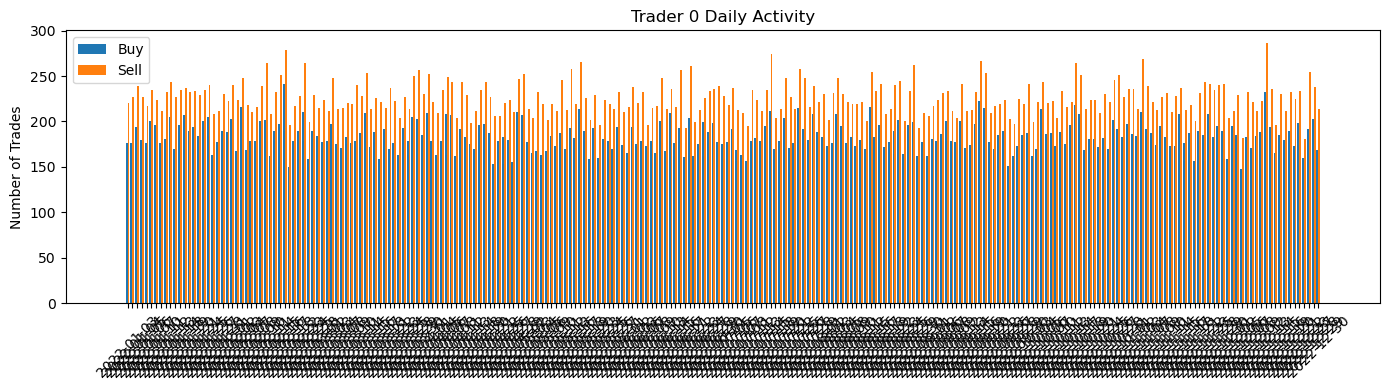

In [491]:
plot_daily_bar(0)

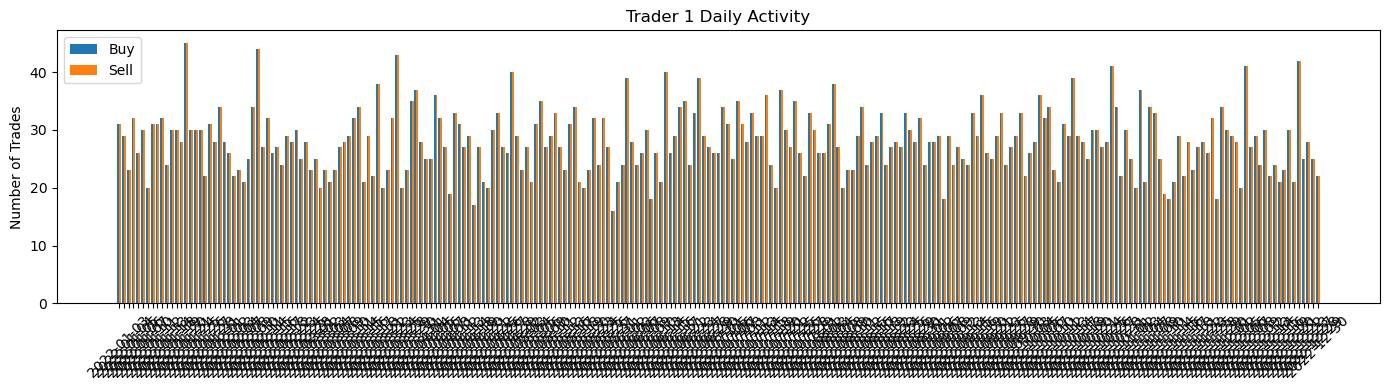

In [493]:
plot_daily_bar(1)

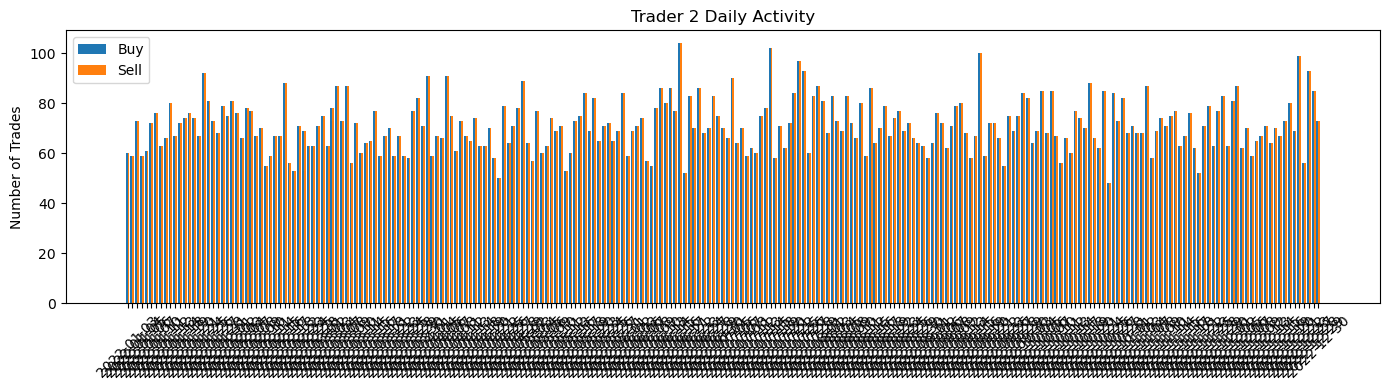

In [495]:
plot_daily_bar(2)

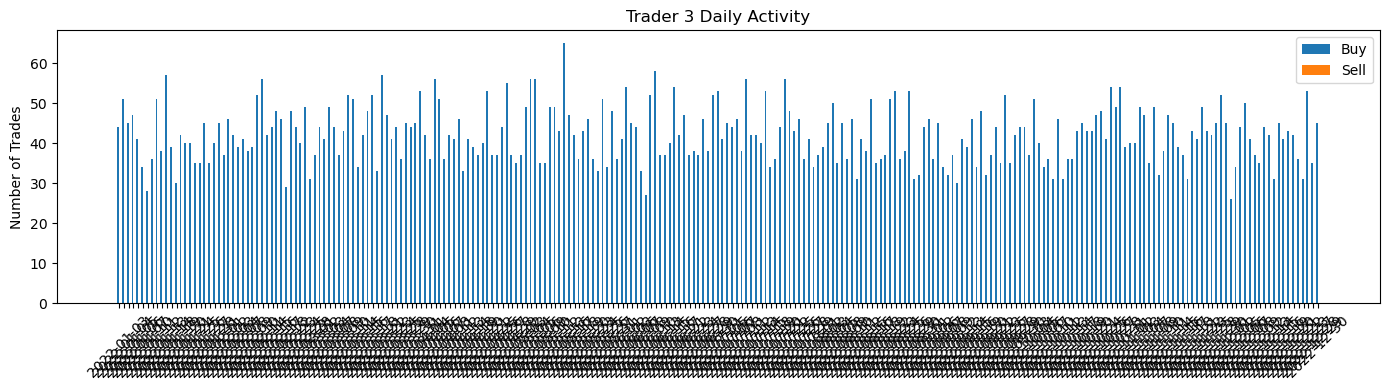

In [497]:
plot_daily_bar(3)

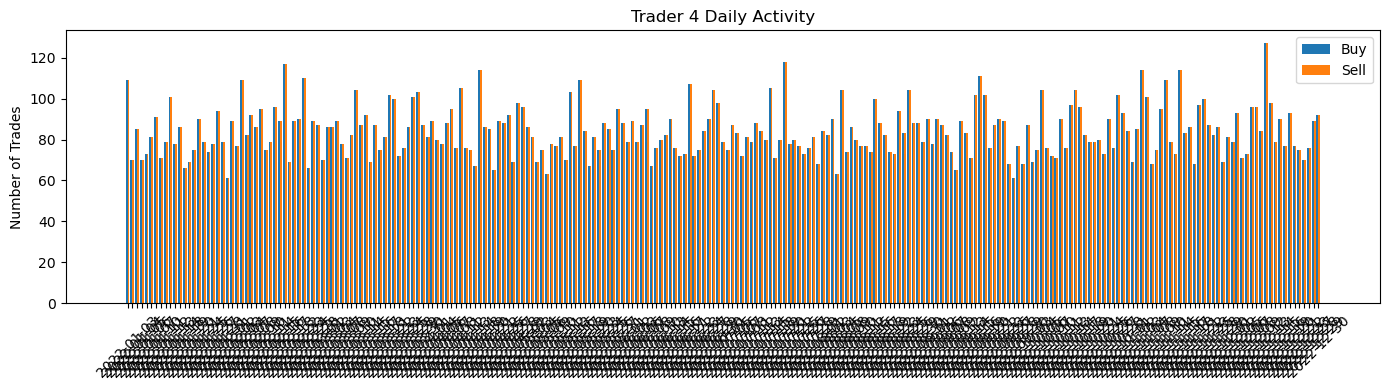

In [499]:
plot_daily_bar(4)

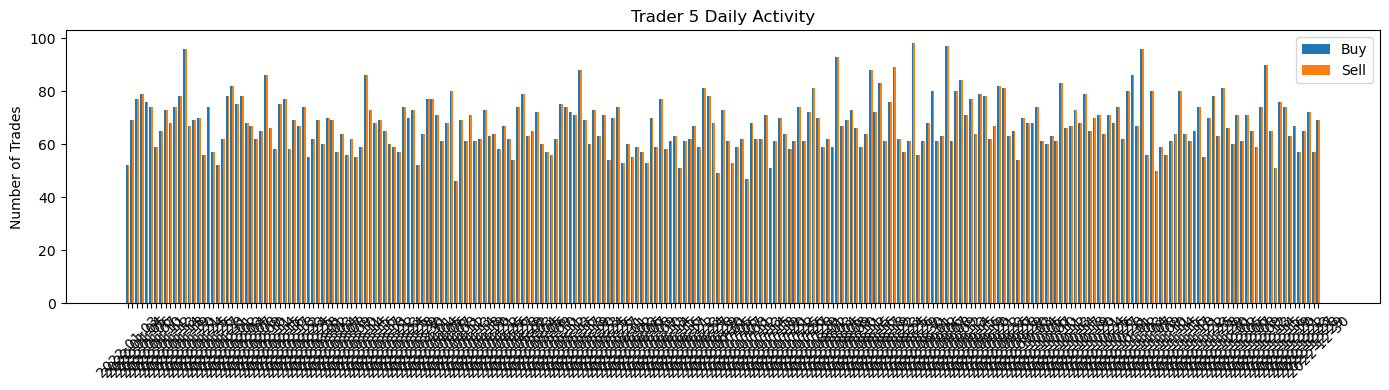

In [501]:
plot_daily_bar(5)

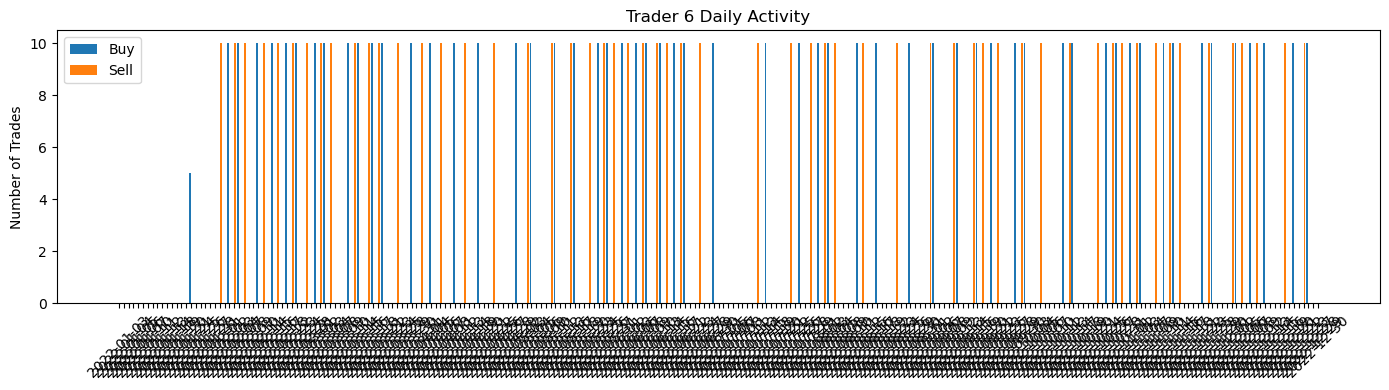

In [503]:
plot_daily_bar(6)

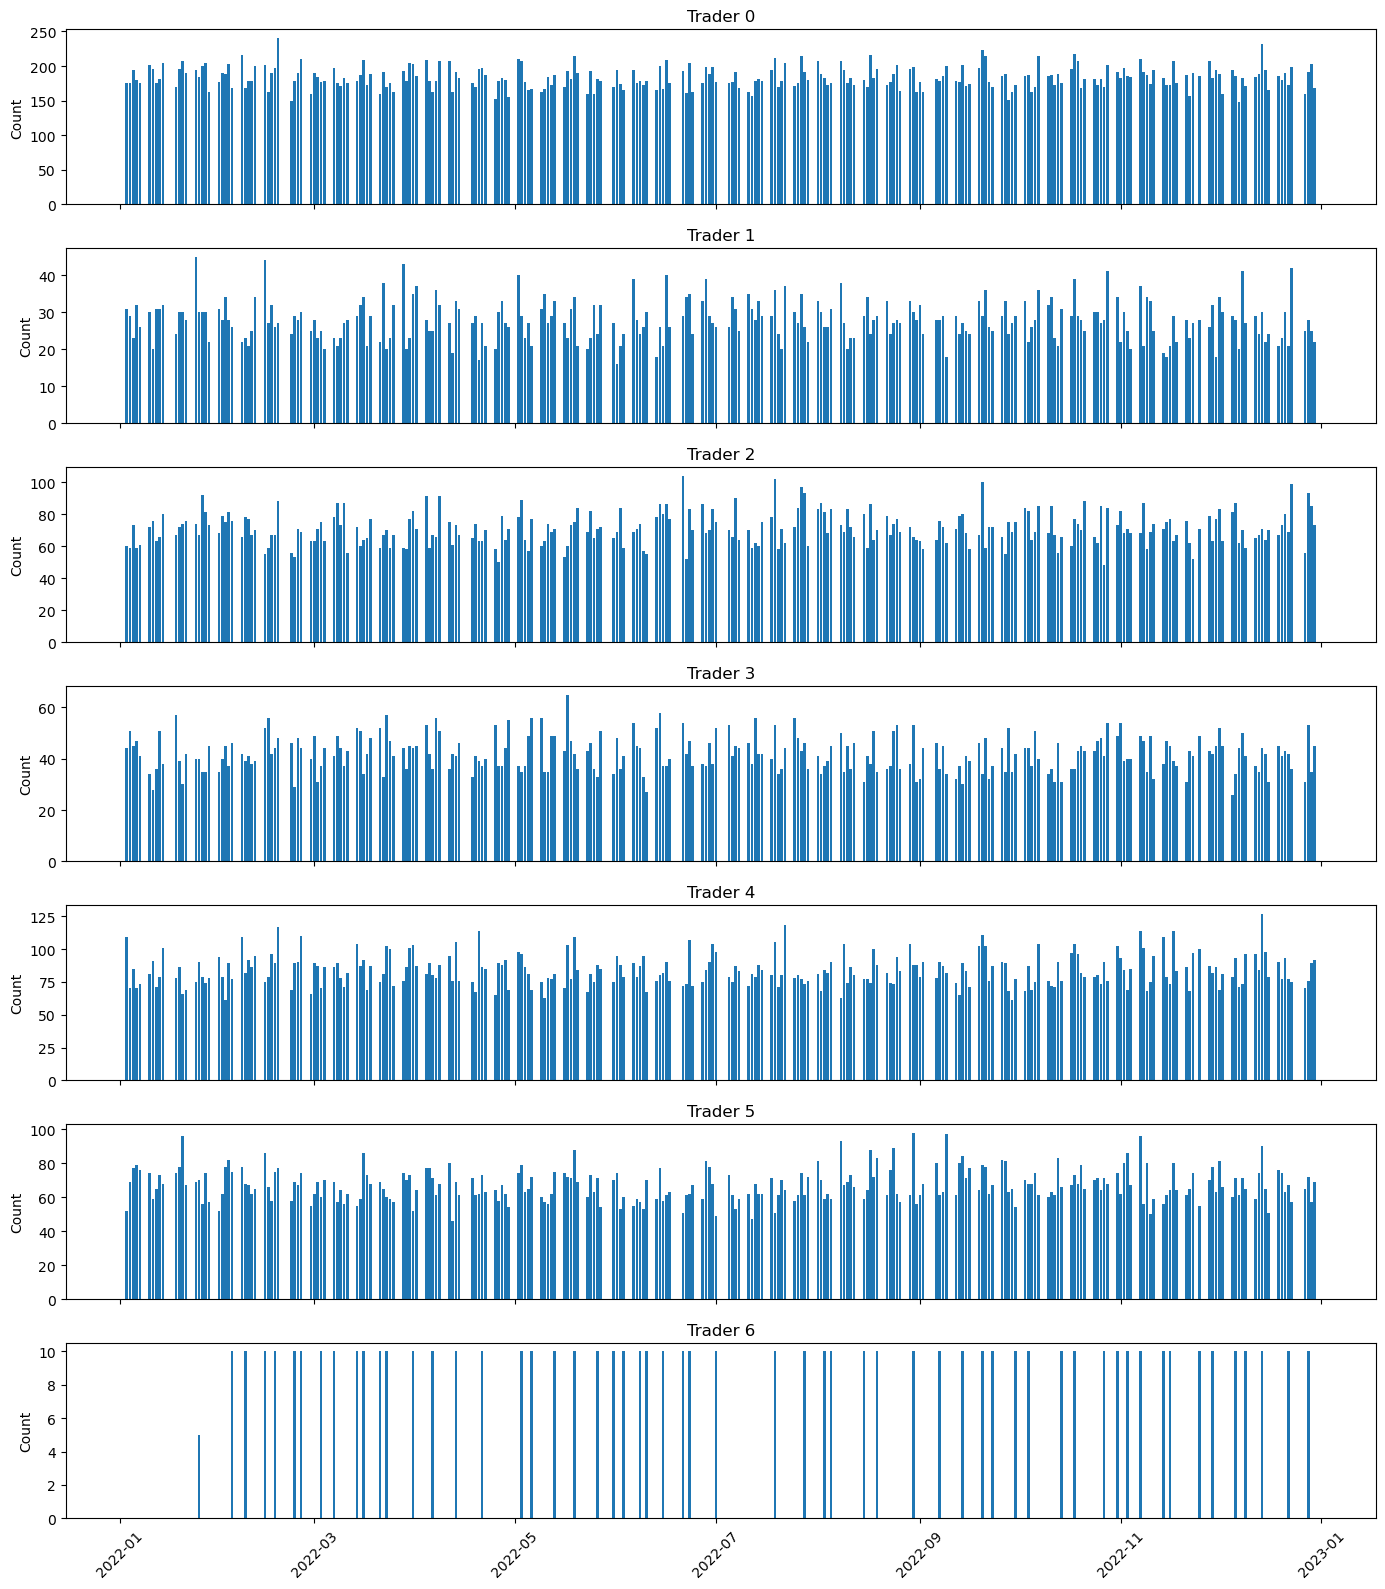

In [505]:
fig, axes = plt.subplots(7, 1, figsize=(14, 16), sharex=True)

for trader_id in range(7):
    axes[trader_id].bar(
        buy_matrix.index,
        buy_matrix.get(trader_id, 0),
    )
    axes[trader_id].set_title(f"Trader {trader_id}")
    axes[trader_id].set_ylabel("Count")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [509]:
buy_dates_6 = (
    bin_df.loc[bin_df["BuyTrader"] == 6, "Date"]
    .drop_duplicates()
    .sort_values()
)

In [511]:
sell_dates_6 = (
    bin_df.loc[bin_df["SellTrader"] == 6, "Date"]
    .drop_duplicates()
    .sort_values()
)


In [515]:
dates6 = pd.DataFrame({
    "BuyDates": pd.Series(buy_dates_6),
    "SellDates": pd.Series(sell_dates_6)
})

In [517]:
dates6

,BuyDates,SellDates
Datetime,,
2022-01-25 10:07:16,2022-01-25,NaN
2022-02-02 10:00:34,NaN,2022-02-02
2022-02-04 10:01:25,2022-02-04,NaN
2022-02-07 10:00:28,NaN,2022-02-07
2022-02-08 10:00:14,2022-02-08,NaN
...,...,...
2022-12-14 10:00:06,2022-12-14,NaN
2022-12-20 10:01:21,NaN,2022-12-20
2022-12-22 10:00:07,2022-12-22,NaN


In [521]:
buy_counts_6 = (
    bin_df[bin_df['BuyTrader']==6]
    .groupby('Date')
    .size()
    .rename('BuyCount')
)

sell_counts_6 = (
    bin_df[bin_df['SellTrader']==6]
    .groupby('Date')
    .size()
    .rename('SellCount')
)

trader6_daily = pd.concat([buy_counts_6, sell_counts_6], axis=1).fillna(0)


In [523]:
trader6_daily.loc[buy_dates_6]

,BuyCount,SellCount
Date,,
2022-01-25,5.0,0.0
2022-02-04,10.0,0.0
2022-02-08,10.0,0.0
2022-02-14,10.0,0.0
2022-02-17,10.0,0.0
2022-02-23,10.0,0.0
2022-02-25,10.0,0.0
2022-03-03,10.0,0.0
2022-03-07,10.0,0.0


In [525]:
trader6_daily.loc[sell_dates_6]

,BuyCount,SellCount
Date,,
2022-02-02,0.0,10.0
2022-02-07,0.0,10.0
2022-02-09,0.0,10.0
2022-02-15,0.0,10.0
2022-02-18,0.0,10.0
2022-02-24,0.0,10.0
2022-03-01,0.0,10.0
2022-03-04,0.0,10.0
2022-03-08,0.0,10.0


In [527]:

# --- parameters ---
TRADER = 6
start_t = pd.to_datetime("10:00:00").time()
end_t   = pd.to_datetime("10:10:00").time()  # inclusive; change if you want [10:00,10:10)

# Ensure Date and Time columns available
tmp = bin_df.copy()
tmp["Date"] = tmp.index.normalize()              # midnight timestamp per day
tmp["Time"] = tmp.index.time

# Flag trades by trader 6
tmp["is_buy6"]  = (tmp["BuyTrader"]  == TRADER)
tmp["is_sell6"] = (tmp["SellTrader"] == TRADER)
tmp["is_trade6"] = tmp["is_buy6"] | tmp["is_sell6"]

# Restrict to rows where trader 6 is involved (faster + cleaner)
t6 = tmp[tmp["is_trade6"]].copy()

# Per-day counts for trader 6
daily_counts = t6.groupby("Date").agg(
    buy_cnt=("is_buy6", "sum"),
    sell_cnt=("is_sell6", "sum"),
    total_cnt=("is_trade6", "sum"),
)

def all_in_window(times):
    # times is a Series of python datetime.time objects for that day (trader 6 trades only)
    return ((times >= start_t) & (times <= end_t)).all()

daily_in_window = (
    t6.groupby("Date")["Time"]
      .apply(all_in_window)
      .rename("all_in_10_00_10_10")
)

daily = daily_counts.join(daily_in_window)

# Define "special" days
sell_days = daily[
    (daily["sell_cnt"] == 10) &
    (daily["buy_cnt"] == 0) &
    (daily["total_cnt"] == 10) &
    (daily["all_in_10_00_10_10"])
].index

buy_days = daily[
    (daily["buy_cnt"] == 10) &
    (daily["sell_cnt"] == 0) &
    (daily["total_cnt"] == 10) &
    (daily["all_in_10_00_10_10"])
].index

# Count sell->buy exactly one day later
sell_to_buy_pairs = sell_days.intersection(buy_days - pd.Timedelta(days=1))
count_sell_to_buy = len(sell_to_buy_pairs)

print("Special sell days:", len(sell_days))
print("Special buy days :", len(buy_days))
print("Sell day followed by buy day (exactly +1 day):", count_sell_to_buy)

# Optional: show the actual paired dates (sell_day, buy_day)
pairs_df = pd.DataFrame({
    "sell_day": sell_to_buy_pairs,
    "buy_day": sell_to_buy_pairs + pd.Timedelta(days=1),
}).sort_values("sell_day")

pairs_df

Special sell days: 57
Special buy days : 57
Sell day followed by buy day (exactly +1 day): 20


,sell_day,buy_day
0,2022-02-07,2022-02-08
1,2022-02-24,2022-02-25
2,2022-03-15,2022-03-16
3,2022-03-22,2022-03-23
4,2022-05-05,2022-05-06
5,2022-05-12,2022-05-13
6,2022-05-18,2022-05-19
7,2022-06-09,2022-06-10
8,2022-06-14,2022-06-15
9,2022-06-22,2022-06-23


In [529]:
buy_to_sell_pairs = buy_days.intersection(sell_days - pd.Timedelta(days=1))
count_buy_to_sell = len(buy_to_sell_pairs)

print("Buy day followed by sell day (exactly +1 day):", count_buy_to_sell)

Buy day followed by sell day (exactly +1 day): 22


In [531]:
pairs_buy_sell = pd.DataFrame({
    "buy_day": buy_to_sell_pairs,
    "sell_day": buy_to_sell_pairs + pd.Timedelta(days=1),
}).sort_values("buy_day")

pairs_buy_sell

,buy_day,sell_day
0,2022-02-08,2022-02-09
1,2022-02-14,2022-02-15
2,2022-02-17,2022-02-18
3,2022-02-23,2022-02-24
4,2022-03-03,2022-03-04
5,2022-03-07,2022-03-08
6,2022-03-14,2022-03-15
7,2022-03-21,2022-03-22
8,2022-05-26,2022-05-27
9,2022-05-31,2022-06-01


In [ ]:
"""
Seems tricky to backtest strategy; need to be able to randomly place a trade at a given time
    but this trade must come from what's already historically written
That is, we can write down strategy for trades but in real-time, we don't know who will trade when
    so can only probabilistically trade with who we want to trade with. If we trade with 2,4,5 for example (who are well-informed),
        we wante to cease trading immediately
    Strategy is adaptive 

eg place Buy orders in times of hours where 0 tends to sell, since 0 is our main ill-informed trader
similarly place Sell orders when 0 tends to buy
avoid placing Buy orders in times when 2,4,5 sell ; in fact, try to sell when they sell (which usually overlaps with 0 buying)
avoid placing Sell orders in times when 2,4,5 buy; try to buy when they buy (which usually overlaps with 0 selling)

if 6 makes a trade, immediately place exact number of same side trades the next day (which is always around 10--10:10) 
    as 6 tends to make opposite trades the next day (and we can profit off of 6 as counterparty)

Would also have to analyze if there's a pattern to who trades when sequentially

also self-reminder:  do confidence intervals for the trader t-scores
"""

In [533]:
"""
Computing probabilities of when each trader is most likely to trade
"""
df = bin_df.copy()
df = df.sort_index()

# 5-min forward bucket returns
price_5 = df["Spot"].resample("5min").last()
ret_5 = price_5.pct_change(fill_method=None).shift(-1)

df["bucket"] = df.index.floor("5min")
df["5minReturn"] = df["bucket"].map(ret_5)
df = df.dropna(subset=["5minReturn"])

# regular session 09:30–16:00 only (optional but recommended)
tod = df.index.time
df = df[(tod >= pd.to_datetime("09:30:00").time()) & (tod <= pd.to_datetime("16:00:00").time())]

# 10-minute intraday bin label b = 0..38
open_dt = df.index.normalize() + pd.Timedelta(hours=9, minutes=30)
df["bin10"] = ((df.index - open_dt).total_seconds() // 600).astype(int)
df = df[(df["bin10"] >= 0) & (df["bin10"] <= 38)]

In [535]:
# buyer mix per 10-min bin
buy_counts = df.groupby(["bin10", "BuyTrader"]).size().rename("n").reset_index()
buy_counts["p_buy"] = buy_counts["n"] / buy_counts.groupby("bin10")["n"].transform("sum")

# seller mix per 10-min bin
sell_counts = df.groupby(["bin10", "SellTrader"]).size().rename("n").reset_index()
sell_counts["p_sell"] = sell_counts["n"] / sell_counts.groupby("bin10")["n"].transform("sum")

In [537]:
p_buy_mat  = buy_counts.pivot(index="bin10", columns="BuyTrader",  values="p_buy").reindex(columns=range(7)).fillna(0)
p_sell_mat = sell_counts.pivot(index="bin10", columns="SellTrader", values="p_sell").reindex(columns=range(7)).fillna(0)

In [539]:
p_buy_mat

BuyTrader,0,1,2,3,4,5,6
bin10,,,,,,,
0,0.396613,0.068056,0.128297,0.094432,0.167372,0.145230,0.000000
1,0.388008,0.056789,0.131980,0.080266,0.185914,0.157043,0.000000
2,0.388041,0.061705,0.138677,0.090013,0.177163,0.144402,0.000000
3,0.337341,0.055061,0.127434,0.081750,0.134648,0.125511,0.138254
4,0.383514,0.066200,0.152769,0.080522,0.176003,0.140993,0.000000
5,0.405142,0.057273,0.146762,0.091767,0.172795,0.126261,0.000000
6,0.390892,0.056293,0.159709,0.082859,0.172359,0.137887,0.000000
7,0.382800,0.057436,0.156163,0.085998,0.186588,0.131015,0.000000
8,0.398810,0.060464,0.159774,0.092732,0.166353,0.121867,0.000000


In [541]:
p_sell_mat

SellTrader,0,1,2,3,4,5,6
bin10,,,,,,,
0,0.459459,0.060567,0.167698,0.0,0.173559,0.138717,0.000000
1,0.456536,0.060279,0.174492,0.0,0.180520,0.128173,0.000000
2,0.450382,0.059160,0.168257,0.0,0.188613,0.133588,0.000000
3,0.388314,0.050733,0.134888,0.0,0.162299,0.126713,0.137052
4,0.458943,0.062381,0.157225,0.0,0.183959,0.137492,0.000000
5,0.440937,0.075171,0.157175,0.0,0.176049,0.150667,0.000000
6,0.456040,0.057242,0.163820,0.0,0.175206,0.147691,0.000000
7,0.454828,0.071406,0.157094,0.0,0.160820,0.155852,0.000000
8,0.446115,0.057018,0.154449,0.0,0.174499,0.167920,0.000000


In [543]:
# Buy-side conditional means per (bin10, trader)
buy_mu = (
    df.groupby(["bucket", "bin10", "BuyTrader"])["5minReturn"].first()
      .reset_index()
      .groupby(["bin10", "BuyTrader"])["5minReturn"]
      .mean()
      .rename("mu_buy")
      .reset_index()
)

# Sell-side conditional means per (bin10, trader)
sell_mu = (
    df.groupby(["bucket", "bin10", "SellTrader"])["5minReturn"].first()
      .reset_index()
      .groupby(["bin10", "SellTrader"])["5minReturn"]
      .mean()
      .rename("mu_sell")
      .reset_index()
)

In [545]:
mu_buy_mat  = buy_mu.pivot(index="bin10", columns="BuyTrader",  values="mu_buy").reindex(columns=range(7)).fillna(0)
mu_sell_mat = sell_mu.pivot(index="bin10", columns="SellTrader", values="mu_sell").reindex(columns=range(7)).fillna(0)

In [547]:
"""
Matrix of conditional means ie if trader i buys in this bin, what's the expected return
"""

mu_buy_mat

BuyTrader,0,1,2,3,4,5,6
bin10,,,,,,,
0,-1.701133e-05,-0.000163,0.000111,0.000053,0.000065,1.123089e-04,0.000000
1,-2.558537e-05,-0.000046,0.000096,-0.000010,0.000053,-2.527377e-05,0.000000
2,-5.209216e-06,-0.000069,0.000162,0.000009,0.000080,7.387322e-05,0.000000
3,-4.285704e-05,-0.000112,0.000081,0.000037,0.000108,3.502287e-05,0.000147
4,-1.178820e-04,-0.000034,0.000067,-0.000102,-0.000049,-2.043070e-04,0.000000
5,-5.434028e-05,0.000021,0.000077,-0.000016,0.000078,1.972680e-04,0.000000
6,2.609711e-05,0.000143,0.000104,0.000106,0.000081,1.168844e-04,0.000000
7,8.151918e-06,0.000131,0.000177,0.000022,0.000140,1.112933e-04,0.000000
8,-4.811151e-05,-0.000007,0.000034,0.000011,0.000053,6.555579e-05,0.000000


In [549]:
alpha_sell = (p_buy_mat * mu_buy_mat).sum(axis=1).rename("alpha_sell")
alpha_buy  = (p_sell_mat * mu_sell_mat).sum(axis=1).rename("alpha_buy")


In [551]:
"""
If you sell in a certain time window, what's your average return?
Want more negative alpha_sell (sell --> price tends to drop)
and more positive alpha_buy (buy --> price tends to rise)
"""

alpha = pd.concat([alpha_sell, alpha_buy], axis=1)
alpha["alpha_sell_bps"] = 1e4 * alpha["alpha_sell"]
alpha["alpha_buy_bps"]  = 1e4 * alpha["alpha_buy"]
alpha

,alpha_sell,alpha_buy,alpha_sell_bps,alpha_buy_bps
bin10,,,,
0,0.000029,-0.000011,0.286415,-0.112511
1,0.000005,0.000002,0.052048,0.023604
2,0.000042,0.000016,0.417719,0.159071
3,0.000032,0.000005,0.320840,0.046347
4,-0.000083,-0.000098,-0.829979,-0.983145
5,0.000027,-0.000023,0.273115,-0.229042
6,0.000074,0.000030,0.736193,0.304268
7,0.000081,0.000035,0.807244,0.353658
8,0.000004,-0.000030,0.036512,-0.297921


In [553]:
K_sell = 5
K_buy  = 5

best_sell_bins = alpha["alpha_sell"].sort_values().head(K_sell).index.tolist()   # most negative
best_buy_bins  = alpha["alpha_buy"].sort_values(ascending=False).head(K_buy).index.tolist()

best_sell_bins, best_buy_bins

([4, 36, 15, 35, 18], [38, 17, 11, 7, 6])

In [ ]:
"""
bins 4, 36, 15, 35, 18 are the best ones to sell in
bins 38, 17, 11, 7, 6 are best ones to buy in

where bin b is the interval [9:30 + 10b , 9:30 + 10*(b+1))

diversify portfolio (minimize variance) by putting trades in different bins, instead of stacking all in one
"""

In [555]:

def bin_to_window(b):
    start = pd.Timestamp("1900-01-01 09:30") + pd.Timedelta(minutes=10*b)
    end   = start + pd.Timedelta(minutes=10)
    return f"{start.strftime('%H:%M')}–{end.strftime('%H:%M')}"

best_sell_bins = [4, 36, 15, 35, 18]
best_buy_bins  = [38, 17, 11, 7, 6]

sell_windows = [(b, bin_to_window(b)) for b in best_sell_bins]
buy_windows  = [(b, bin_to_window(b)) for b in best_buy_bins]

sell_windows, buy_windows

([(4, '10:10–10:20'),
  (36, '15:30–15:40'),
  (15, '12:00–12:10'),
  (35, '15:20–15:30'),
  (18, '12:30–12:40')],
 [(38, '15:50–16:00'),
  (17, '12:20–12:30'),
  (11, '11:20–11:30'),
  (7, '10:40–10:50'),
  (6, '10:30–10:40')])